In [1]:
# ============================================================
# LANGKAH 1: Load & EDA Singkat
# ============================================================

from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=malignant, 1=benign

# Cek shape data
print("=" * 60)
print("LANGKAH 1: Load & EDA Singkat")
print("=" * 60)
print(f"\nShape data: {X.shape}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

# Cek distribusi target
print("\nDistribusi target:")
dist = pd.Series(y).value_counts()
print(dist)
print("\nDistribusi target (proporsi):")
print(pd.Series(y).value_counts(normalize=True).round(3))

# Cek beberapa baris pertama data
print("\n5 baris pertama data:")
print(X.head())

# Cek statistik deskriptif
print("\nStatistik deskriptif (ringkasan):")
print(X.describe().round(2))

# Cek korelasi antar fitur utama (top 10 fitur)
print("\nKorelasi antar fitur utama (top 10):")
corr_matrix = X.corr()
# Ambil korelasi dengan target terlebih dahulu
X_with_target = X.copy()
X_with_target['target'] = y
corr_with_target = X_with_target.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print("\nTop 10 fitur paling berkorelasi dengan target:")
print(corr_with_target.head(10).round(3))

# Cek missing values
print(f"\nMissing values: {X.isnull().sum().sum()}")

LANGKAH 1: Load & EDA Singkat

Shape data: (569, 30)
Jumlah fitur: 30
Jumlah sampel: 569

Distribusi target:
1    357
0    212
Name: count, dtype: int64

Distribusi target (proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64

5 baris pertama data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790

In [2]:
# ============================================================
# LANGKAH 2: Preprocessing
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 60)
print("LANGKAH 2: Preprocessing")
print("=" * 60)

# Train-Test Split 80:20 dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran data training: {X_train.shape}")
print(f"Ukuran data testing: {X_test.shape}")
print(f"\nDistribusi target di training set:")
print(pd.Series(y_train).value_counts())
print(f"\nDistribusi target di testing set:")
print(pd.Series(y_test).value_counts())

# Terapkan StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nData berhasil di-scale dengan StandardScaler")
print(f"Mean fitur training set (setelah scaling, 5 fitur pertama): {X_train_s.mean(axis=0)[:5].round(6)}")
print(f"Std fitur training set (setelah scaling, 5 fitur pertama): {X_train_s.std(axis=0)[:5].round(3)}")


LANGKAH 2: Preprocessing

Ukuran data training: (455, 30)
Ukuran data testing: (114, 30)

Distribusi target di training set:
1    285
0    170
Name: count, dtype: int64

Distribusi target di testing set:
1    72
0    42
Name: count, dtype: int64

Data berhasil di-scale dengan StandardScaler
Mean fitur training set (setelah scaling, 5 fitur pertama): [-0.  0. -0.  0.  0.]
Std fitur training set (setelah scaling, 5 fitur pertama): [1. 1. 1. 1. 1.]


In [3]:
# ============================================================
# LANGKAH 3: Latih Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

print("\n" + "=" * 60)
print("LANGKAH 3: Latih Logistic Regression")
print("=" * 60)

# Fit LogisticRegression pada data yang sudah distandarisasi
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

# Prediksi
y_pred_log = log_model.predict(X_test_s)

# Tampilkan koefisien (fitur paling berpengaruh)
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("\nTop 10 fitur paling berpengaruh (berdasarkan koefisien):")
print(coef_df.head(10).to_string(index=False))

print(f"\nIntercept (β₀): {log_model.intercept_[0]:.4f}")
print(f"Jumlah iterasi konvergensi: {log_model.n_iter_[0]}")

# Interpretasi koefisien
print("\nInterpretasi:")
print("- Koefisien POSITIF → meningkatkan probabilitas kelas 1 (Benign)")
print("- Koefisien NEGATIF → meningkatkan probabilitas kelas 0 (Malignant)")


LANGKAH 3: Latih Logistic Regression

Top 10 fitur paling berpengaruh (berdasarkan koefisien):
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625

Intercept (β₀): 0.3022
Jumlah iterasi konvergensi: 19

Interpretasi:
- Koefisien POSITIF → meningkatkan probabilitas kelas 1 (Benign)
- Koefisien NEGATIF → meningkatkan probabilitas kelas 0 (Malignant)



LANGKAH 4: Latih Decision Tree

Top 10 fitur paling penting (Feature Importance):
               Fitur  Importance
        worst radius    0.733548
worst concave points    0.122028
       texture error    0.045785
       worst texture    0.032319
     worst concavity    0.017161
 mean concave points    0.013327
          area error    0.012704
        mean texture    0.011846
      worst symmetry    0.011282
           mean area    0.000000

Kedalaman pohon: 4
Jumlah leaf nodes: 11

Visualisasi pohon disimpan sebagai 'decision_tree_visualization.png'


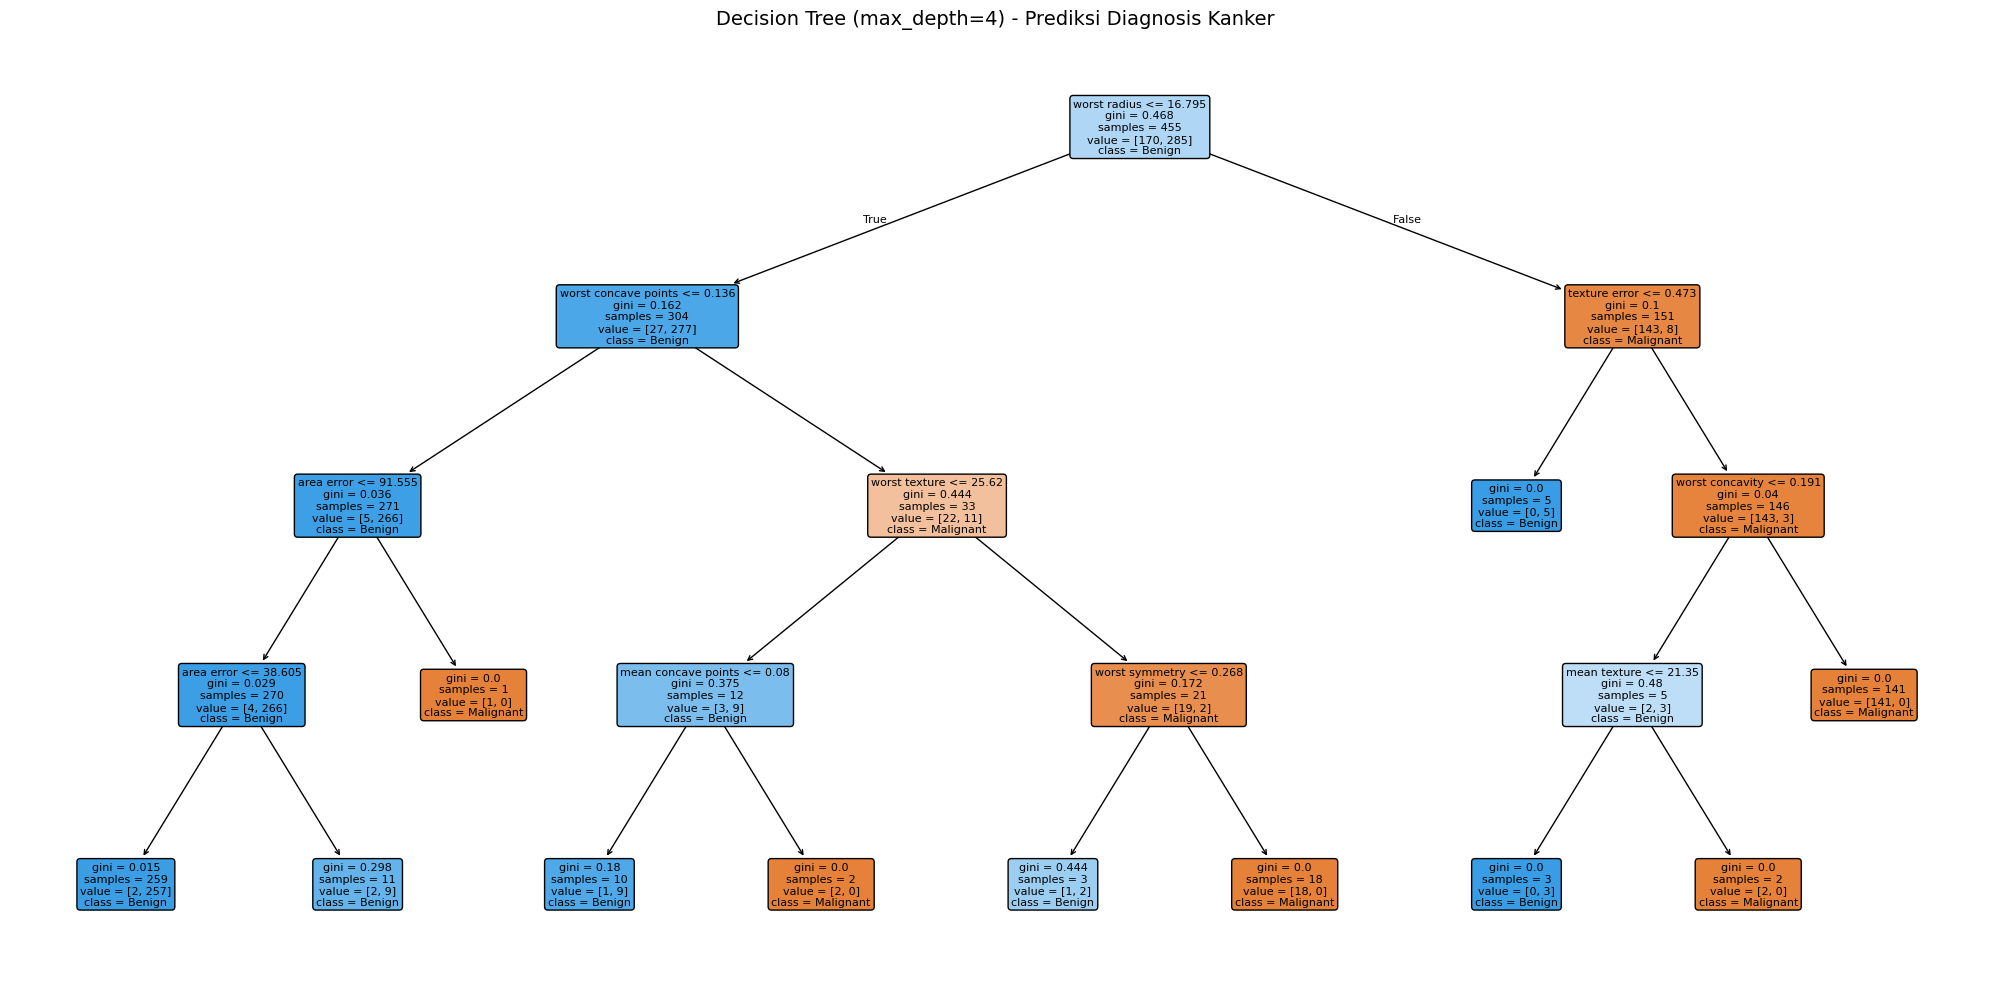

In [4]:
# ============================================================
# LANGKAH 4: Latih Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("LANGKAH 4: Latih Decision Tree")
print("=" * 60)

# Fit DecisionTreeClassifier pada data asli (tanpa scaling)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

# Feature importance
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 fitur paling penting (Feature Importance):")
print(importance_df.head(10).to_string(index=False))

print(f"\nKedalaman pohon: {tree_model.get_depth()}")
print(f"Jumlah leaf nodes: {tree_model.get_n_leaves()}")

# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns.tolist(),
          class_names=['Malignant', 'Benign'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree (max_depth=4) - Prediksi Diagnosis Kanker", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
print("\nVisualisasi pohon disimpan sebagai 'decision_tree_visualization.png'")
plt.show()

In [5]:
# ============================================================
# LANGKAH 5: Evaluasi & Bandingkan
# ============================================================

from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

print("\n" + "=" * 60)
print("LANGKAH 5: Evaluasi & Bandingkan")
print("=" * 60)

# Evaluasi kedua model
models = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_tree
}

results = []

for name, y_pred in models.items():
    print(f"\n{'=' * 40}")
    print(f"  {name}")
    print(f"{'=' * 40}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
    print(f"  FN={cm[1][0]}  TP={cm[1][1]}")

    # Metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nAccuracy  : {acc:.3f} ({acc*100:.1f}%)")
    print(f"Precision : {prec:.3f} ({prec*100:.1f}%)")
    print(f"Recall    : {rec:.3f} ({rec*100:.1f}%)")
    print(f"F1-Score  : {f1:.3f} ({f1*100:.1f}%)")

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Tabel perbandingan
print("\n" + "=" * 60)
print("TABEL PERBANDINGAN KEDUA MODEL")
print("=" * 60)

comparison_df = pd.DataFrame(results).set_index('Model')
print(f"\n{comparison_df.round(3).to_string()}")

# Analisis
print("\n" + "=" * 60)
print("ANALISIS")
print("=" * 60)

best_recall = comparison_df['Recall'].idxmax()
best_f1 = comparison_df['F1-Score'].idxmax()
best_acc = comparison_df['Accuracy'].idxmax()

print(f"""
1. Model dengan Recall tertinggi : {best_recall} ({comparison_df.loc[best_recall, 'Recall']:.3f})
2. Model dengan F1-Score tertinggi: {best_f1} ({comparison_df.loc[best_f1, 'F1-Score']:.3f})
3. Model dengan Accuracy tertinggi: {best_acc} ({comparison_df.loc[best_acc, 'Accuracy']:.3f})

Kesimpulan:
- Untuk kasus diagnosis kanker, RECALL adalah metrik paling kritis karena
  False Negative (kanker yang terlewat) jauh lebih berbahaya daripada
  False Positive (pemeriksaan lanjutan yang tidak perlu).
- Model dengan Recall lebih tinggi lebih disarankan untuk kasus medis.
- Perbedaan performa kedua model dapat dilihat dari tabel perbandingan di atas.
""")


LANGKAH 5: Evaluasi & Bandingkan

  Logistic Regression

Confusion Matrix:
  TN=41  FP=1
  FN=1  TP=71

Accuracy  : 0.982 (98.2%)
Precision : 0.986 (98.6%)
Recall    : 0.986 (98.6%)
F1-Score  : 0.986 (98.6%)

  Decision Tree

Confusion Matrix:
  TN=39  FP=3
  FN=4  TP=68

Accuracy  : 0.939 (93.9%)
Precision : 0.958 (95.8%)
Recall    : 0.944 (94.4%)
F1-Score  : 0.951 (95.1%)

TABEL PERBANDINGAN KEDUA MODEL

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     0.982      0.986   0.986     0.986
Decision Tree           0.939      0.958   0.944     0.951

ANALISIS

1. Model dengan Recall tertinggi : Logistic Regression (0.986)
2. Model dengan F1-Score tertinggi: Logistic Regression (0.986)
3. Model dengan Accuracy tertinggi: Logistic Regression (0.982)

Kesimpulan:
- Untuk kasus diagnosis kanker, RECALL adalah metrik paling kritis karena
  False Negative (kanker yang terlewat) jauh lebih berbahaya dar